# 01. Introduction to ViennaRNA: Predicting RNA Secondary Structure

## Learning objectives

By the end of this notebook you will be able to:

- explain, in words and in one equation, what an **MFE (minimum free energy) secondary
  structure** prediction is and why it is needed;
- describe the intuition behind the **nearest-neighbor thermodynamic model** that
  ViennaRNA uses to score structures;
- read and write **dot-bracket notation** and convert it to explicit base-pair
  coordinates;
- predict the MFE structure of a sequence with the Python `RNA` module
  (`RNA.fold` and `RNA.fold_compound`);
- visualize a predicted structure using several complementary tools — an arc
  diagram, a mountain plot, a pairing-matrix heatmap, ViennaRNA's native SVG
  renderer, and **`forgi`**'s element-type-colored structure diagrams — and explain
  what each view emphasizes;
- run an equivalent prediction via the `RNAfold` command-line tool and check that
  the two interfaces agree;
- list the main limitations of a single MFE prediction, so you don't over-interpret
  it.

**Prerequisites:** comfortable with basic Python, pandas, and matplotlib/seaborn;
you know that RNA is a sequence over the alphabet `{A, C, G, U}` and that it can fold
back on itself. No prior ViennaRNA experience is assumed.


## 1. Introduction and motivation

### Why RNA structure matters

An RNA molecule is not just a linear message — it folds back on itself, and that
fold often *is* its function. Transfer RNAs fold into a cloverleaf/L-shape required
for translation; riboswitches change shape to turn genes on or off in response to a
small molecule; microRNA precursors are processed based on their hairpin shape; and
structure in untranslated regions of messenger RNA can speed up or shut down
translation. If you want to understand, design, or debug any of these systems, the
first question is almost always: **what structure does this sequence fold into?**

### Why this is a hard computational problem

A sequence of length $n$ can in principle form an enormous number of distinct
secondary structures — far too many to enumerate one by one even for a short
sequence. We need (1) a way to *score* how favorable a given structure is, and (2) an
algorithm that can find the best-scoring structure without checking every
possibility individually. ViennaRNA provides both: a thermodynamic scoring model
(Section 2) and efficient dynamic-programming algorithms built on top of it.

### Where ViennaRNA fits

[ViennaRNA](https://www.tbi.univie.ac.at/RNA/) is one of the most widely used open
source toolkits for RNA secondary structure prediction and analysis. It ships both a
command-line suite (`RNAfold`, `RNAcofold`, `RNAalifold`, ...) and a Python binding
(the `RNA` module) that wraps the same C library. This tutorial track uses the Python
binding so that everything is reproducible inside a notebook, while also showing the
command-line equivalent for the basic case. For visualization, we pair ViennaRNA with
**[`forgi`](https://github.com/ViennaRNA/forgi)** — a Python library, maintained by
the same group, that uses ViennaRNA's own structure layout but renders it through
matplotlib with each structural element (stems, loops, multiloops, ...) colored by
type.

### Roadmap for this notebook

This is lesson 1 of a 10-lesson track (see `ViennaRNA_Tutorial_Plan.md`). Everything
later in the series — partition functions, suboptimal structures, constraints,
comparative folding — builds on the single-sequence MFE workflow introduced here. We
will:

1. build the theoretical picture of what "minimum free energy structure" means;
2. learn dot-bracket notation and how to turn it into several complementary pictures;
3. run our first MFE fold and visualize it natively and with `forgi`;
4. compare folds across a handful of sequences;
5. introduce **fold compounds**, the object-oriented interface used throughout the
   rest of the series, and check it against the command-line `RNAfold`;
6. run a small "screening" case study;
7. step back and discuss best practices and common pitfalls.


## 2. Theoretical background: scoring and finding structures

### 2.1 Secondary structure as a set of base pairs

A **secondary structure** for a sequence $x = x_1 x_2 \ldots x_n$ is a set of base
pairs $s = \{(i, j)\}$ such that:

- each position $i$ appears in at most one pair (every base is either paired or
  unpaired);
- pairs don't cross: if $(i, j)$ and $(k, l)$ are both in $s$ with $i < k$, then
  either $i < k < l < j$ (nested) or $j < k$ (disjoint) — pairs may not "interleave"
  ($i < k < j < l$ is forbidden);
- pairs respect a minimum loop size (by default ViennaRNA requires at least 3
  unpaired bases between $i$ and $j$, since the RNA backbone can't bend tighter than
  that).

**Dot-bracket notation** writes this compactly as a string of the same length as the
sequence:

- `(` = this base is the *left* partner of a pair,
- `)` = this base is the *right* partner of a pair (matching the most recent
  unmatched `(`),
- `.` = this base is unpaired.

For example `(((...)))` over `GGGAAACCC` means positions 1-3 pair with positions 9-7
(in that order), and positions 4-6 are unpaired — a simple **hairpin**: a *stem* of
three base pairs closing a *loop* of three unpaired bases.

### 2.2 Scoring a structure: the nearest-neighbor model

Not all valid structures are equally likely. ViennaRNA scores a structure using the
**nearest-neighbor (Turner) energy model**: the structure is decomposed into small
structural elements — *stacked base pairs (stems)*, *hairpin loops*, *bulges*,
*interior loops*, and *multiloops* — and the total free energy is the sum of each
element's contribution:

$$
\Delta G(s \mid x) = \sum_{\text{loop } l \in s} \Delta G(l)
$$

The individual $\Delta G(l)$ values come from decades of experimental measurements
(melting experiments on small synthetic RNAs) tabulated as a function of the
nucleotides involved and the loop type/size. Two intuitions matter most for this
notebook:

- **Stacked GC pairs are usually the most stabilizing** (most negative $\Delta G$)
  contribution, because G-C pairs have three hydrogen bonds and stack well.
- **Loops cost free energy** (positive $\Delta G$ contribution), because constraining
  a piece of single-stranded RNA into a loop reduces its entropy. Longer loops
  generally cost less per-nucleotide than very short ones, but any loop is a
  destabilizing term relative to having no loop at all.

So a structure's total $\Delta G$ is a trade-off: more/better stacked pairs make
$\Delta G$ more negative (more favorable), while loops push it back up. This same
*stem vs. loop* decomposition is exactly what the `forgi`-based diagrams in this
notebook color-code — so the pictures and the formula describe the same elements.

### 2.3 The MFE problem

Given the scoring function above, the **minimum free energy (MFE) structure** is the
lowest-scoring structure over *all* valid secondary structures $\mathcal{S}(x)$ of
the sequence:

$$
s^* = \arg\min_{s \,\in\, \mathcal{S}(x)} \Delta G(s \mid x)
$$

Because the energy decomposes into independent contributions from nested
substructures, $s^*$ can be found with a **dynamic programming** algorithm (the
Zuker algorithm and its descendants) in roughly $O(n^3)$ time and $O(n^2)$ memory —
without ever enumerating $\mathcal{S}(x)$ explicitly. This is the algorithm running
underneath `RNA.fold`.

### 2.4 Connecting theory to the API

| Concept above | ViennaRNA API below |
| :--- | :--- |
| sequence $x$ | a Python string over `ACGU` |
| structure $s$ | a dot-bracket string |
| $\Delta G(s \mid x)$, in kcal/mol at 37°C by default | the second return value of `RNA.fold(x)` |
| $s^*$ (the MFE structure) | the first return value of `RNA.fold(x)` |
| "sequence + model settings" bundle, reused for other calculations later in the series | `RNA.fold_compound(x)` |
| individual loop elements (stem, hairpin, interior loop, multiloop, ...) | the colored elements in a `forgi` structure diagram |

A more negative MFE means the model considers the structure energetically more
favorable than the fully unfolded chain — but, as we'll discuss in Section 9, that is
*not* the same as a guarantee about what the molecule does in a cell.


## 3. Setup

This cell imports the ViennaRNA Python binding (`RNA`), the `forgi` structure-drawing
library, sets up plotting with a consistent `seaborn` theme and color palette (used
throughout the notebook so that every figure looks like part of the same document),
and checks whether the `RNAfold` command-line executable is available. The notebook
works fully from the Python API alone — the CLI check is only used in Section 7.

> **Note on the `forgi` import:** the installed build of `forgi` prints a harmless
> NumPy ABI compatibility warning to stderr on import. We import it inside
> `contextlib.redirect_stderr` to keep that cosmetic warning out of the notebook
> output; it does not affect correctness.


In [1]:
import contextlib
import io
import re
import shutil
import subprocess
import tempfile
from collections import Counter
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, SVG, display

import RNA

with contextlib.redirect_stderr(io.StringIO()):
    import forgi.graph.bulge_graph as fgb
    import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
PALETTE = sns.color_palette("deep")
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 170,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

rnafold_path = shutil.which("RNAfold")
print(f"ViennaRNA Python module version: {getattr(RNA, '__version__', 'unknown')}")
print(f"forgi version: {getattr(__import__('forgi'), '__version__', 'unknown')}")
print(f"seaborn version: {sns.__version__}")
print(f"RNAfold executable: {rnafold_path if rnafold_path else 'not found; CLI-style cell will use a Python fallback'}")


ViennaRNA Python module version: 2.7.2
forgi version: 2.2.3
seaborn version: 0.13.2
RNAfold executable: /home/zivbental/miniconda3/bin/RNAfold


### Interpretation

This output is not a biological result — it just tells us which interfaces and
visualization tools are available. The Python module is what the rest of this
notebook uses; the `RNAfold` executable is only needed for Section 7, where we
cross-check the command-line workflow.


## 4. From dot-bracket strings to pictures

Before running any predictions, it helps to be fluent in dot-bracket notation. The
helper below turns a dot-bracket string into explicit `(left, right)` base-pair
coordinates and a readable table. We then build **four complementary views** of the
same structure — each highlighting something different:

- an **arc diagram**: pairs drawn as arcs above the sequence, preserving 5'-to-3'
  order;
- a **mountain plot**: a classic RNA-structure visualization that plots pairing
  *depth* against sequence position — stems look like slopes and loops look like
  flat tops/valleys;
- a **pairing-matrix heatmap** (via `seaborn.heatmap`): pairs as filled cells in an
  $n \times n$ grid, the representation most natural for algorithms;
- a **`forgi` structure diagram**: ViennaRNA's own 2D layout, rendered through
  matplotlib with each nucleotide colored by the type of structural element it
  belongs to (green = stem, blue = hairpin loop, ...). Section 5 introduces the full
  color legend.


In [2]:
def dotbracket_to_pairs(structure):
    """Return 1-indexed base-pair tuples from a simple dot-bracket string."""
    stack = []
    pairs = []

    for position, symbol in enumerate(structure, start=1):
        if symbol == "(":
            stack.append(position)
        elif symbol == ")":
            if not stack:
                raise ValueError(f"Unmatched closing parenthesis at position {position}")
            pairs.append((stack.pop(), position))
        elif symbol != ".":
            raise ValueError(f"Unsupported symbol {symbol!r} at position {position}")

    if stack:
        raise ValueError(f"Unmatched opening parenthesis at positions {stack}")

    return pairs


def pair_table(sequence, structure):
    """Build a readable table of paired positions and nucleotide identities."""
    rows = []
    for left, right in dotbracket_to_pairs(structure):
        rows.append({
            "left_position": left,
            "left_base": sequence[left - 1],
            "right_position": right,
            "right_base": sequence[right - 1],
            "pair": f"{sequence[left - 1]}-{sequence[right - 1]}",
        })
    return pd.DataFrame(rows)

example_sequence = "GGGAAACCC"
example_structure = "(((...)))"

print(example_sequence)
print(example_structure)
display(pair_table(example_sequence, example_structure))


GGGAAACCC
(((...)))


,left_position,left_base,right_position,right_base,pair
0,3,G,7,C,G-C
1,2,G,8,C,G-C
2,1,G,9,C,G-C


/tmp/ipykernel_27544/663850278.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


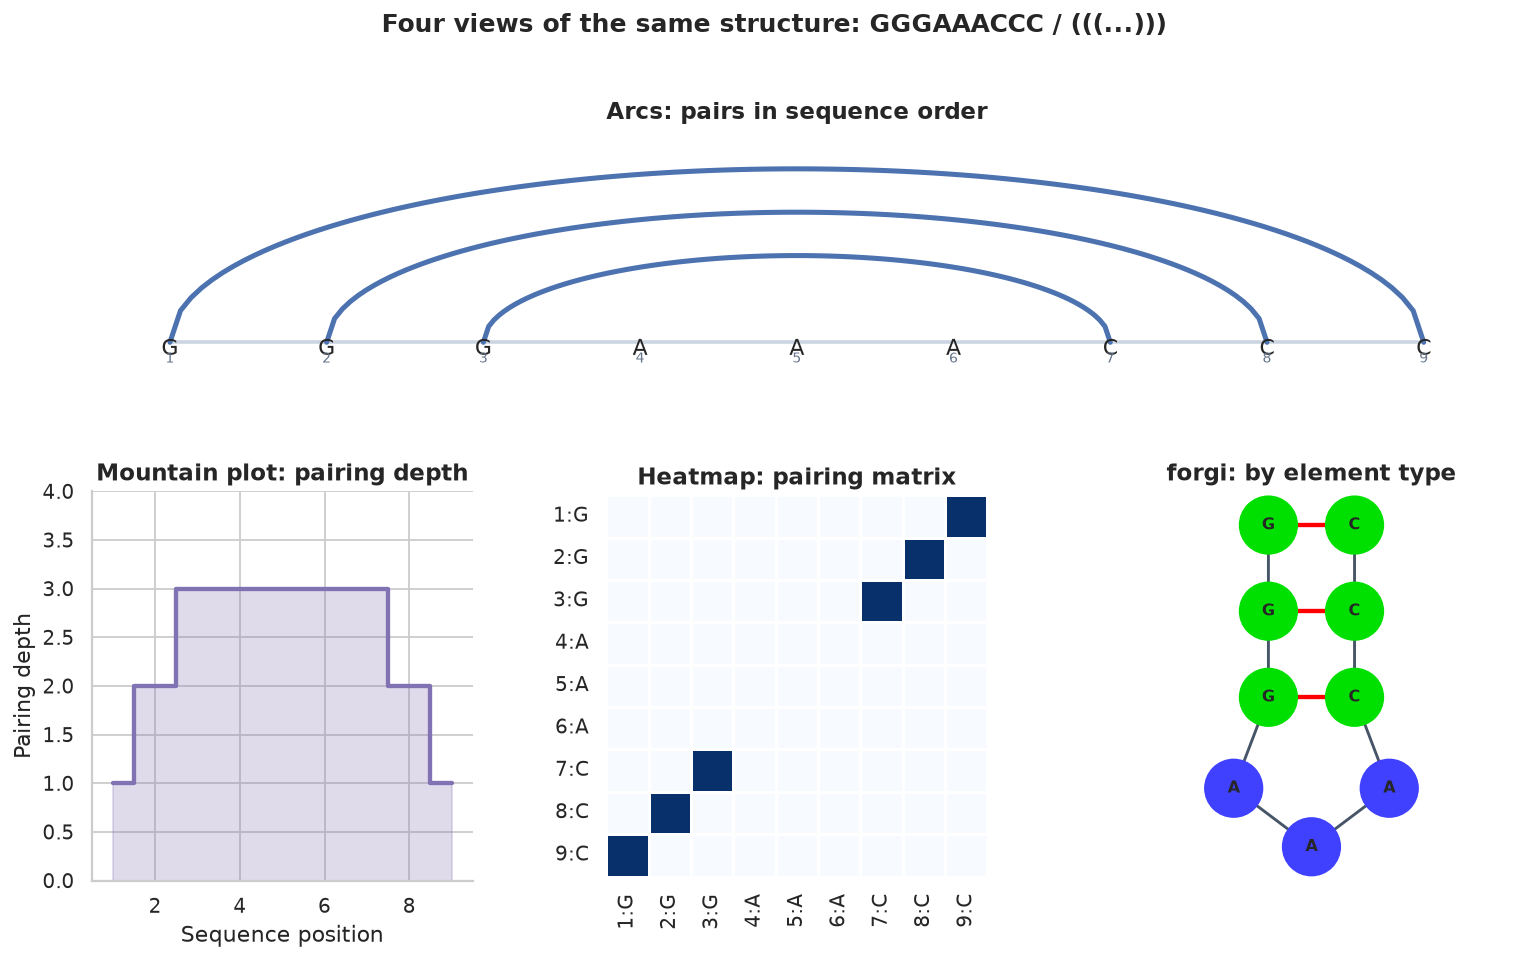

In [3]:
PAIR_COLORS = {
    "G-C": PALETTE[0],
    "C-G": PALETTE[0],
    "A-U": PALETTE[2],
    "U-A": PALETTE[2],
    "G-U": PALETTE[1],
    "U-G": PALETTE[1],
}

# forgi's default element -> color mapping (see forgi.visual.mplotlib.plot_rna)
FORGI_ELEMENT_LEGEND = {
    "s": ("green", "Stem (stacked base pairs)"),
    "h": ("blue", "Hairpin loop"),
    "i": ("yellow", "Interior loop / bulge"),
    "m": ("red", "Multiloop junction"),
    "f": ("orange", "Single-stranded / dangling end"),
    "t": ("orange", "Single-stranded / dangling end"),
}


def pair_label(sequence, left, right):
    return f"{sequence[left - 1]}-{sequence[right - 1]}"


def plot_arc_diagram(sequence, structure, ax, title=None):
    """Draw base pairs as arcs above the sequence (preserves 5'->3' order)."""
    n = len(sequence)
    positions = np.arange(1, n + 1)
    ax.plot(positions, np.zeros(n), color="#CBD5E1", linewidth=2, zorder=1)

    for position, base in zip(positions, sequence):
        ax.text(position, -0.16, base, ha="center", va="center", fontsize=12)
        ax.text(position, -0.38, str(position), ha="center", va="center", fontsize=8, color="#64748B")

    for left, right in dotbracket_to_pairs(structure):
        center = (left + right) / 2
        radius = (right - left) / 2
        xs = np.linspace(left, right, 120)
        ys = np.sqrt(np.maximum(radius**2 - (xs - center)**2, 0))
        color = PAIR_COLORS.get(pair_label(sequence, left, right), PALETTE[3])
        ax.plot(xs, ys, color=color, linewidth=2.8, zorder=2)

    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(-0.55, max(1.0, n / 2 + 0.4))
    ax.axis("off")
    ax.set_title(title or "Arc diagram")


def loop_depth_profile(structure):
    """Per-position pairing depth: rises by 1 at '(' and falls by 1 after ')'."""
    depth = 0
    profile = []
    for symbol in structure:
        if symbol == "(":
            depth += 1
            profile.append(depth)
        elif symbol == ")":
            profile.append(depth)
            depth -= 1
        else:
            profile.append(depth)
    return profile


def plot_mountain(sequence, structure, ax, title=None, color=None):
    """Classic RNA 'mountain plot': pairing depth vs. sequence position."""
    color = color or PALETTE[4]
    positions = np.arange(1, len(sequence) + 1)
    depths = loop_depth_profile(structure)
    ax.step(positions, depths, where="mid", color=color, linewidth=2.4)
    ax.fill_between(positions, depths, step="mid", color=color, alpha=0.25)
    ax.set_xlim(0.5, len(sequence) + 0.5)
    ax.set_ylim(0, max(depths) + 1)
    ax.set_xlabel("Sequence position")
    ax.set_ylabel("Pairing depth")
    ax.set_title(title or "Mountain plot")
    sns.despine(ax=ax)


def plot_pairing_matrix(sequence, structure, ax, title=None):
    """Pairing matrix as a seaborn heatmap (1 = paired positions)."""
    n = len(sequence)
    matrix = np.zeros((n, n), dtype=int)
    for left, right in dotbracket_to_pairs(structure):
        matrix[left - 1, right - 1] = 1
        matrix[right - 1, left - 1] = 1

    labels = [f"{i}:{base}" for i, base in enumerate(sequence, start=1)]
    sns.heatmap(
        matrix, ax=ax, cmap="Blues", cbar=False, square=True, linewidths=0.6,
        linecolor="white", xticklabels=labels, yticklabels=labels,
    )
    ax.set_title(title or "Pairing matrix")
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)


def plot_forgi_structure(sequence, structure, ax, title=None, lighten=0.25, annotate_elements=True):
    """Draw a structure with forgi: ViennaRNA's own layout, colored by element type."""
    bg = fgb.BulgeGraph.from_dotbracket(structure, sequence)
    fvm.plot_rna(
        bg,
        ax=ax,
        lighten=lighten,
        text_kwargs={"fontweight": "bold", "fontsize": 9},
        backbone_kwargs={"linewidth": 1.6, "color": "#475569"},
        basepair_kwargs={"linewidth": 2.4},
        annotations={} if annotate_elements else None,
    )
    ax.set_aspect("equal")
    ax.set_title(title or "forgi structure diagram")


def lighten_color(color, amount):
    """Lighten a color the same way forgi's plot_rna does, for legend consistency."""
    import colorsys
    import matplotlib.colors as mcolors

    h, l, s = colorsys.rgb_to_hls(*mcolors.to_rgb(color))
    l += (1 - l) * min(1, amount)
    return colorsys.hls_to_rgb(h, l, s)


def forgi_legend_handles(*structures, lighten=0.25):
    """Build legend patches for the forgi element types present in the given structures."""
    present = set()
    for structure in structures:
        present.update(set(fgb.BulgeGraph.from_dotbracket(structure).to_element_string()))

    handles = {}
    for code_, (color, label) in FORGI_ELEMENT_LEGEND.items():
        if code_ in present and label not in handles:
            handles[label] = mpatches.Patch(
                facecolor=lighten_color(color, lighten), edgecolor="black", alpha=0.9, label=label,
            )
    return list(handles.values())


fig = plt.figure(figsize=(14, 7.5))
gs = fig.add_gridspec(2, 3, height_ratios=[0.85, 1.4], hspace=0.4, wspace=0.35)
ax_arc = fig.add_subplot(gs[0, :])
ax_mountain = fig.add_subplot(gs[1, 0])
ax_matrix = fig.add_subplot(gs[1, 1])
ax_forgi = fig.add_subplot(gs[1, 2])

plot_arc_diagram(example_sequence, example_structure, ax=ax_arc, title="Arcs: pairs in sequence order")
plot_mountain(example_sequence, example_structure, ax=ax_mountain, title="Mountain plot: pairing depth")
plot_pairing_matrix(example_sequence, example_structure, ax=ax_matrix, title="Heatmap: pairing matrix")
plot_forgi_structure(example_sequence, example_structure, ax=ax_forgi, title="forgi: by element type", annotate_elements=False)

fig.suptitle(f"Four views of the same structure: {example_sequence} / {example_structure}", y=1.0, fontsize=14, fontweight="bold")
fig.tight_layout()


### Interpretation

All four plots encode exactly the same three base pairs as the table above. The arc
diagram is useful for humans because it preserves sequence order; the mountain plot
turns the hairpin into a literal "mountain" — depth rises through the stem and stays
flat across the loop, then falls back to zero; the heatmap is the representation most
natural for algorithms, since it is literally an array; and the `forgi` diagram shows
ViennaRNA's own 2D layout with the stem (green) and hairpin loop (blue) colored by
element type — the same vocabulary as Section 2.2. A common beginner mistake is to
treat the *drawing style* as part of the prediction — all four are purely
representations of the same dot-bracket string, nothing more.


## 5. Worked example 1: your first MFE fold

We now connect the theory in Section 2 to code. `RNA.fold(sequence)` runs the
dynamic-programming MFE algorithm and returns `(structure, energy)` — exactly $s^*$
and $\Delta G(s^* \mid x)$ from Section 2.3. We'll fold the same tiny GC hairpin used
above, summarize it in a table, and then draw it two ways: with ViennaRNA's **native**
SVG renderer (`RNA.svg_rna_plot`) — the tool's default output — and with **`forgi`**,
which uses the same underlying layout but renders it through matplotlib with a
color-coded legend for structural elements.


,name,sequence,length,MFE structure,MFE energy (kcal/mol),base pairs,GC fraction
0,tiny GC hairpin,GGGAAACCC,9,(((...))),-1.2,3,0.67


**ViennaRNA's native SVG output (RNA.svg_rna_plot)**

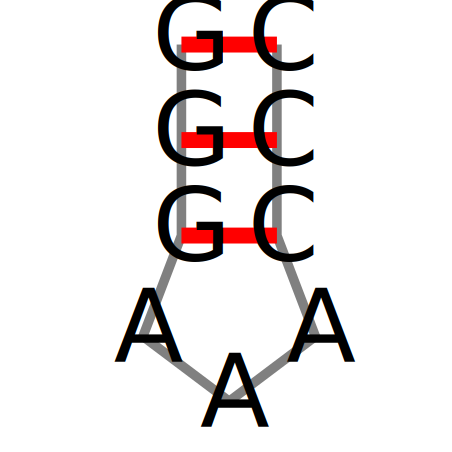

In [4]:
def fold_sequence(name, sequence):
    """Fold one sequence with RNA.fold and return a compact result dictionary."""
    structure, energy = RNA.fold(sequence)
    return {
        "name": name,
        "sequence": sequence,
        "length": len(sequence),
        "MFE structure": structure,
        "MFE energy (kcal/mol)": round(float(energy), 2),
        "base pairs": len(dotbracket_to_pairs(structure)),
        "GC fraction": round((sequence.count("G") + sequence.count("C")) / len(sequence), 2),
    }


def vienna_svg_data(sequence, structure):
    """Render a structure with ViennaRNA's native SVG plotter and return SVG text."""
    with tempfile.TemporaryDirectory() as tmpdir:
        svg_path = Path(tmpdir) / "structure.svg"
        result_code = RNA.svg_rna_plot(sequence, structure, str(svg_path))
        if result_code == 0 or not svg_path.exists():
            raise RuntimeError("ViennaRNA did not produce an SVG structure drawing")
        return svg_path.read_text()


def display_vienna_structure(sequence, structure, title):
    display(Markdown(f"**{title}**"))
    display(SVG(data=vienna_svg_data(sequence, structure)))


toy_result = fold_sequence("tiny GC hairpin", example_sequence)
display(pd.DataFrame([toy_result]))

display_vienna_structure(
    toy_result["sequence"],
    toy_result["MFE structure"],
    "ViennaRNA's native SVG output (RNA.svg_rna_plot)",
)


### Visualization: the same fold through `forgi`

`forgi` reuses ViennaRNA's coordinate layout but colors each nucleotide by the
structural element it belongs to, and adds a legend so the mapping from Section 2.2
("stems vs. loops") to the picture is explicit.


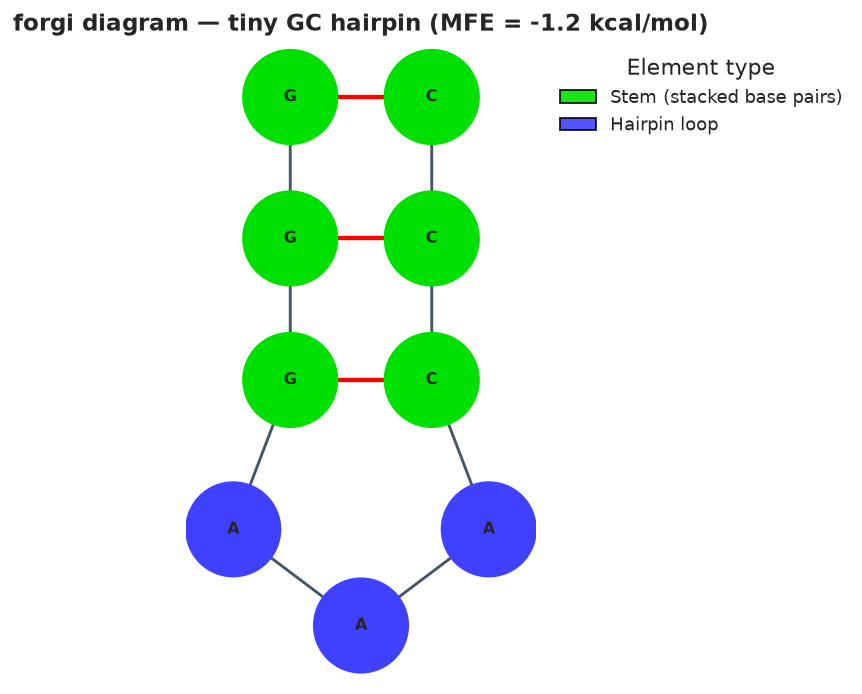

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
plot_forgi_structure(
    toy_result["sequence"],
    toy_result["MFE structure"],
    ax=ax,
    title=f"forgi diagram — {toy_result['name']} (MFE = {toy_result['MFE energy (kcal/mol)']} kcal/mol)",
)
ax.legend(
    handles=forgi_legend_handles(toy_result["MFE structure"]),
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    fontsize=10,
    title="Element type",
)
fig.tight_layout()


### Interpretation

The predicted structure is the three-base-pair hairpin we already analyzed by hand in
Section 4 — `RNA.fold` confirms it is also the *minimum free energy* structure, with
$\Delta G \approx -1.2$ kcal/mol. ViennaRNA's native SVG and the `forgi` diagram show
the *same* layout; `forgi` adds the green/blue element-type coloring and legend. The
negative energy means the model considers this fold more favorable than the fully
unfolded chain ($\Delta G = 0$); it does **not** mean this is the only structure the
sequence can ever adopt — Section 9 returns to this point, and a later notebook
introduces the full ensemble via the partition function.


## 6. Worked example 2: sequence composition and predicted stability

Section 2.2 argued that GC-rich stacks tend to be the most stabilizing element in the
energy model. Let's check that intuition — *cautiously* — across a few short
sequences. We compute the **GC fraction**

$$
\text{GC fraction} = \frac{\#G + \#C}{\text{sequence length}}
$$

and compare it with the predicted MFE energy and base-pair count for four toy
sequences: two GC-rich hairpins of different lengths, an AU-rich hairpin, and an
unstructured poly-A control.


In [6]:
candidate_sequences = [
    ("tiny GC hairpin", "GGGAAACCC"),
    ("longer GC hairpin", "GGGCGAAAGCGCCC"),
    ("AU-rich hairpin", "AAAAUUUU"),
    ("unstructured poly-A", "AAAAAAAAAAAA"),
]

fold_summary = pd.DataFrame([fold_sequence(name, sequence) for name, sequence in candidate_sequences])
display(fold_summary)


,name,sequence,length,MFE structure,MFE energy (kcal/mol),base pairs,GC fraction
0,tiny GC hairpin,GGGAAACCC,9,(((...))),-1.2,3,0.67
1,longer GC hairpin,GGGCGAAAGCGCCC,14,(((((....))))),-8.1,5,0.79
2,AU-rich hairpin,AAAAUUUU,8,........,0.0,0,0.00
3,unstructured poly-A,AAAAAAAAAAAA,12,............,0.0,0,0.00


### Visualization: composition and stability, two different chart types

The left panel is a **stacked horizontal bar chart** of base composition — a natural
fit for "parts of a whole" per sequence. The right panel is a **seaborn scatter
plot** relating GC fraction (x), MFE energy (y), and base-pair count (point size) —
a natural fit for relating several continuous quantities across sequences.


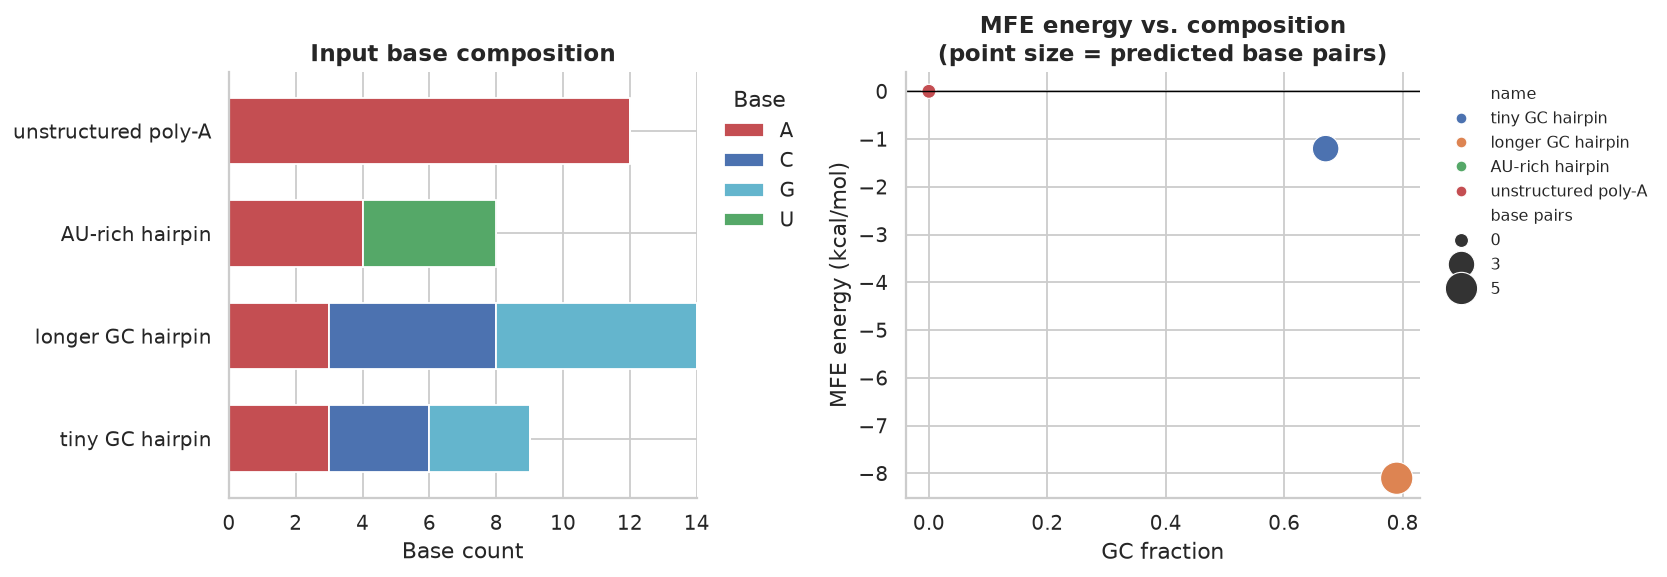

In [7]:
def base_composition_table(named_sequences):
    rows = []
    for name, sequence in named_sequences:
        counts = Counter(sequence)
        for base in ["A", "C", "G", "U"]:
            rows.append({"name": name, "base": base, "count": counts.get(base, 0)})
    return pd.DataFrame(rows)

composition = base_composition_table(candidate_sequences)
composition_pivot = composition.pivot(index="name", columns="base", values="count").fillna(0)
composition_pivot = composition_pivot.loc[fold_summary["name"]]  # keep a consistent order

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.1]})

composition_pivot[["A", "C", "G", "U"]].plot(
    kind="barh",
    stacked=True,
    color=[PALETTE[3], PALETTE[0], PALETTE[9], PALETTE[2]],
    ax=axes[0],
    width=0.65,
)
axes[0].set_xlabel("Base count")
axes[0].set_ylabel("")
axes[0].set_title("Input base composition")
axes[0].legend(title="Base", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine(ax=axes[0])

sns.scatterplot(
    data=fold_summary,
    x="GC fraction",
    y="MFE energy (kcal/mol)",
    size="base pairs",
    hue="name",
    sizes=(60, 320),
    palette="deep",
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("MFE energy vs. composition\n(point size = predicted base pairs)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
sns.despine(ax=axes[1])

fig.tight_layout()


### Interpretation

In this toy set, the GC-rich sequences form more base pairs (larger points) and have
more negative MFE energies, consistent with Section 2.2. The poly-A sequence has no
canonical complementary bases, so ViennaRNA predicts it as fully unpaired (energy 0,
the "unfolded reference"). The AU-rich hairpin is short and only modestly stable. **Do
not** generalize this to "more GC always means more stable" — energy also depends on
loop sizes, stacking context, mismatches, and sequence length; this chart is a
starting diagnostic, not a thermodynamic law.

### Visualization: structured vs. unstructured, side by side with `forgi`

Let's look at the most- and least-structured sequences from this set together in one
figure, sharing a single legend.


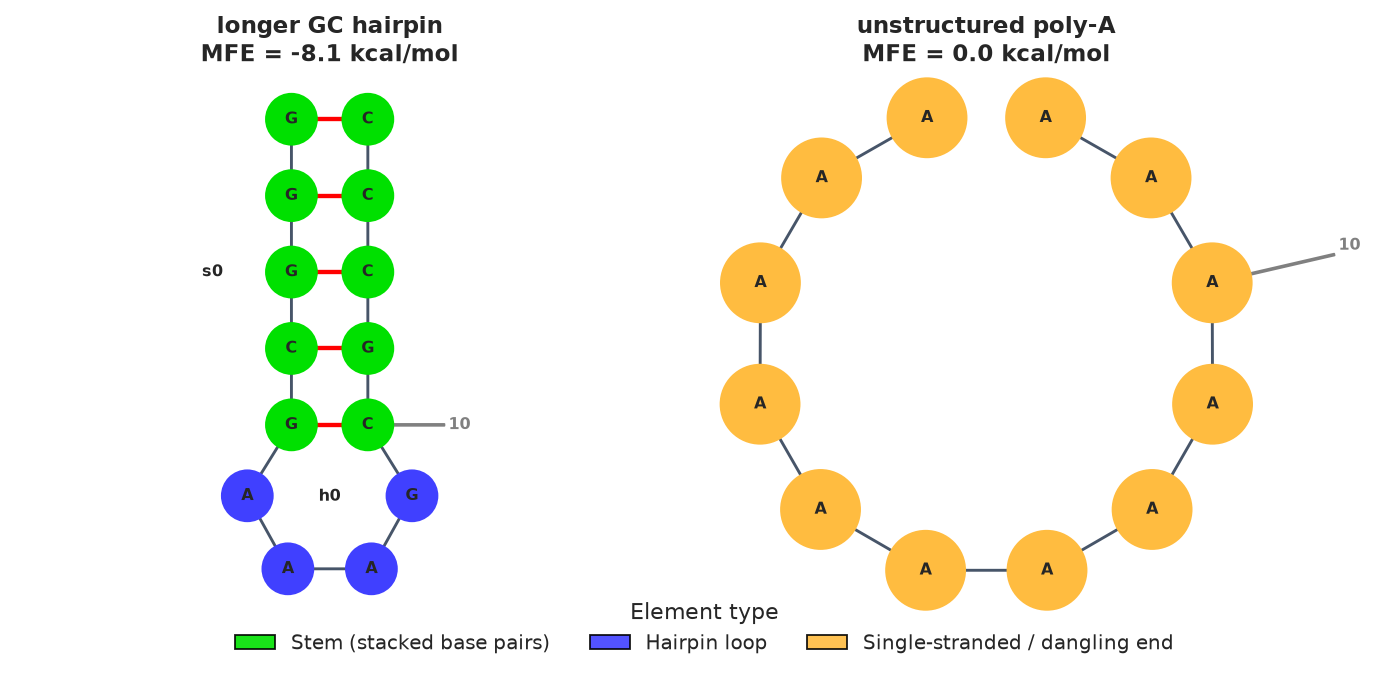

In [8]:
structured = fold_summary.loc[fold_summary["name"] == "longer GC hairpin"].iloc[0]
unstructured = fold_summary.loc[fold_summary["name"] == "unstructured poly-A"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, result in zip(axes, [structured, unstructured]):
    plot_forgi_structure(
        result["sequence"],
        result["MFE structure"],
        ax=ax,
        title=f"{result['name']}\nMFE = {result['MFE energy (kcal/mol)']} kcal/mol",
    )

handles = forgi_legend_handles(structured["MFE structure"], unstructured["MFE structure"])
fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False, bbox_to_anchor=(0.5, -0.05), title="Element type")
fig.tight_layout()


### Interpretation

The GC-rich sequence is drawn as a clear stem-loop (green stem, blue hairpin loop);
the poly-A sequence is drawn as a single-stranded ring, entirely the "single-stranded
/ dangling end" color, because its MFE structure is all dots. A drawing can look
visually "simple" even when the underlying modeling question (e.g., "is this *really*
unstructured, or just not the MFE structure?") is non-trivial — always read a
structure diagram together with its dot-bracket string and energy.


## 7. Worked example 3: fold compounds and the command-line workflow

### Theory: why fold compounds?

`RNA.fold(sequence)` is convenient, but most ViennaRNA workflows — including the rest
of this tutorial series — use a **fold compound**: an object that bundles the
sequence together with model settings (temperature, energy parameters, constraints),
and then exposes methods for different calculations on that same bundle:

$$
\text{sequence + model settings} \;\longrightarrow\; \texttt{fold\_compound} \;\longrightarrow\; \text{MFE, partition function, constraints, probabilities, ...}
$$

For a single MFE call, `RNA.fold_compound(sequence).mfe()` gives the same answer as
`RNA.fold(sequence)`. The reason to learn it now is that later notebooks (partition
functions, constraints, suboptimal structures) all start from the *same* fold
compound object — you just call different methods on it.

### Theory: the command-line equivalent

ViennaRNA is also widely used from the shell. The basic command-line workflow for a
single sequence is:

```bash
echo GGGAAACCC | RNAfold --noPS
```

`--noPS` suppresses the automatic PostScript structure-drawing files, which is useful
in notebooks and repositories where we don't want generated files to accumulate.

### Code approach

The next cell (a) builds a fold compound and calls `.mfe()`, (b) calls `RNAfold`
through `subprocess` if available (falling back to `RNA.fold` otherwise), and (c)
compares all three results in one table.


In [9]:
def parse_rnafold_output(output):
    """Parse standard RNAfold output into sequence, structure, and energy."""
    lines = [line.strip() for line in output.splitlines() if line.strip()]
    if len(lines) < 2:
        raise ValueError(f"Unexpected RNAfold output: {output!r}")

    match = re.match(r"^([().]+)\s+\(\s*([-0-9.]+)\)$", lines[1])
    if not match:
        raise ValueError(f"Could not parse RNAfold structure line: {lines[1]!r}")

    return {
        "sequence": lines[0],
        "MFE structure": match.group(1),
        "MFE energy (kcal/mol)": round(float(match.group(2)), 2),
    }


def run_rnafold_cli_style(sequence):
    executable = shutil.which("RNAfold")
    if executable is None:
        structure, energy = RNA.fold(sequence)
        return {
            "interface": "Python fallback; RNAfold executable not found",
            "sequence": sequence,
            "MFE structure": structure,
            "MFE energy (kcal/mol)": round(float(energy), 2),
        }

    completed = subprocess.run(
        [executable, "--noPS"],
        input=sequence + "\n",
        text=True,
        capture_output=True,
        check=True,
    )
    parsed = parse_rnafold_output(completed.stdout)
    parsed["interface"] = f"RNAfold CLI ({Path(executable).name})"
    return parsed


# (a) fold compound
fold_compound = RNA.fold_compound(example_sequence)
compound_structure, compound_energy = fold_compound.mfe()

# (b) CLI-style
cli_result = run_rnafold_cli_style(example_sequence)

# (c) compare all three
api_comparison = pd.DataFrame([
    {
        "interface": "RNA.fold(sequence)",
        "sequence": toy_result["sequence"],
        "MFE structure": toy_result["MFE structure"],
        "MFE energy (kcal/mol)": toy_result["MFE energy (kcal/mol)"],
    },
    {
        "interface": "RNA.fold_compound(sequence).mfe()",
        "sequence": example_sequence,
        "MFE structure": compound_structure,
        "MFE energy (kcal/mol)": round(float(compound_energy), 2),
    },
    {
        "interface": cli_result["interface"],
        "sequence": cli_result["sequence"],
        "MFE structure": cli_result["MFE structure"],
        "MFE energy (kcal/mol)": cli_result["MFE energy (kcal/mol)"],
    },
])

display(api_comparison)


,interface,sequence,MFE structure,MFE energy (kcal/mol)
0,RNA.fold(sequence),GGGAAACCC,(((...))),-1.2
1,RNA.fold_compound(sequence).mfe(),GGGAAACCC,(((...))),-1.2
2,RNAfold CLI (RNAfold),GGGAAACCC,(((...))),-1.2


### Visualization: API agreement chart

If all three interfaces use compatible ViennaRNA settings, the bars below should be
identical for this basic example. We use `seaborn.barplot` so each bar gets a
distinct color from our shared palette automatically.


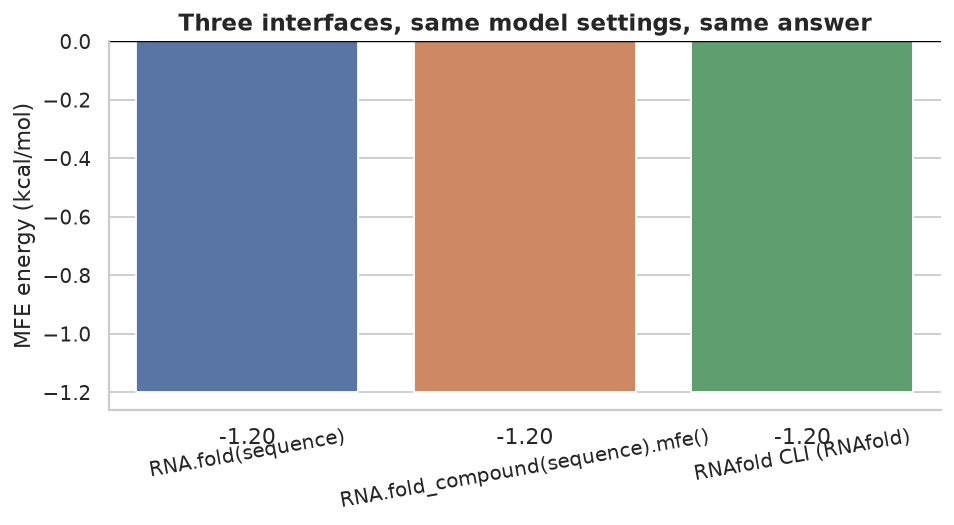

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.barplot(
    data=api_comparison,
    x="interface",
    y="MFE energy (kcal/mol)",
    hue="interface",
    palette="deep",
    legend=False,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Three interfaces, same model settings, same answer")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=10)
for index, value in enumerate(api_comparison["MFE energy (kcal/mol)"]):
    ax.text(index, value - 0.12 if value < 0 else value + 0.05, f"{value:.2f}",
            ha="center", va="top" if value < 0 else "bottom")
sns.despine(ax=ax)
fig.tight_layout()


### Workflow diagram: why fold compounds are worth learning

```
  RNA sequence  -->  fold compound  -->  calculations          -->  outputs
  GGGAAACCC          sequence +          .mfe(), later .pf(),       structure +
                      model settings      .subopt(), constraints     energy, ...
```

### Interpretation

For this introductory MFE task, all three interfaces agree: `RNA.fold`,
`fold_compound.mfe()`, and the `RNAfold` CLI give the same structure and energy. The
fold compound looks more verbose for this single call, but it is the object you will
reuse — without re-specifying the sequence or model — for partition functions,
suboptimal structures, and constrained folding in later notebooks. If Python and CLI
results ever disagree in a real project, the first things to check are **package
versions** and **model settings** (temperature, energy parameter set); in this
environment the Python module and the `RNAfold` executable may come from different
installations, so agreement here is a useful sanity check, not a guarantee for every
option combination.


## 8. Mini case study: screening candidate hairpins

### Theory

A practical first use of ViennaRNA is *screening* a small set of candidate sequences,
asking three questions:

1. Does the predicted MFE structure have the intended shape (e.g., a stem-loop)?
2. Is the predicted energy meaningfully below zero (i.e., the model favors folding
   over the unfolded state)?
3. Do negative controls (sequences with no intended structure) behave as expected?

### Code approach

We fold four candidates — two intended hairpins of different stem strength, a weak
AU-rich hairpin, and an unstructured negative control — apply a simple pass/fail
screen, and visualize the ranking with a **lollipop chart** (a clean way to rank
discrete items by a continuous value) before drawing the strongest and weakest
structures with `forgi`.


In [11]:
screen_sequences = [
    ("candidate A: short stem", "GGGAAACCC"),
    ("candidate B: longer stem", "GGGCGAAAGCGCCC"),
    ("candidate C: weak AU", "AAAUUU"),
    ("negative control", "AAAAAAAAAAAA"),
]

screen = pd.DataFrame([fold_sequence(name, sequence) for name, sequence in screen_sequences])
screen["passes simple screen"] = (screen["base pairs"] >= 3) & (screen["MFE energy (kcal/mol)"] < -1.0)
display(screen)


,name,sequence,length,MFE structure,MFE energy (kcal/mol),base pairs,GC fraction,passes simple screen
0,candidate A: short stem,GGGAAACCC,9,(((...))),-1.2,3,0.67,True
1,candidate B: longer stem,GGGCGAAAGCGCCC,14,(((((....))))),-8.1,5,0.79,True
2,candidate C: weak AU,AAAUUU,6,......,0.0,0,0.00,False
3,negative control,AAAAAAAAAAAA,12,............,0.0,0,0.00,False


### Visualization: ranked screening view

Candidates are sorted by predicted MFE energy. Stem and marker color encode whether a
candidate passes the simple pass/fail screen; the dashed line marks an (illustrative)
energy cutoff.


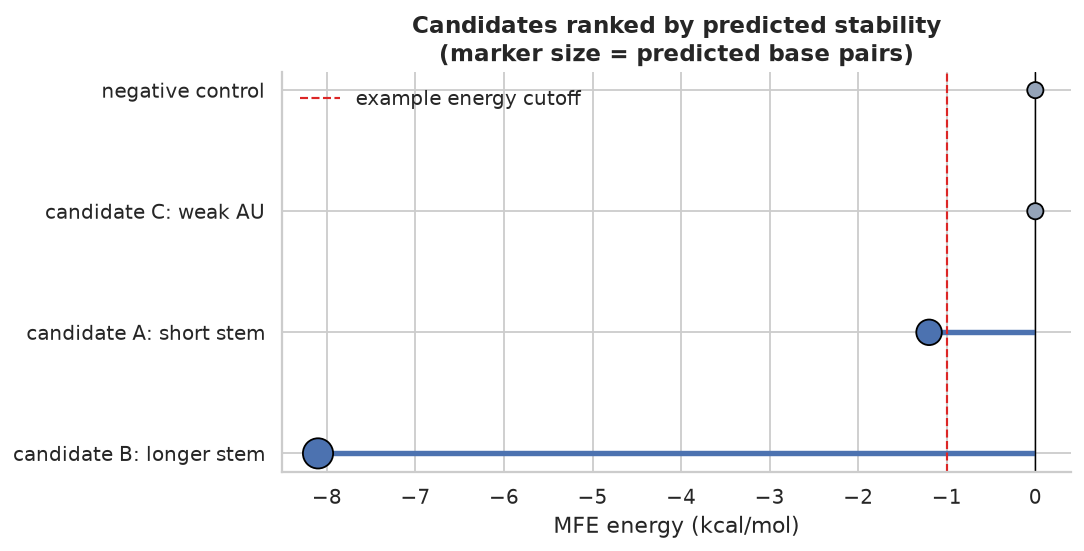

In [12]:
screen_sorted = screen.sort_values("MFE energy (kcal/mol)").reset_index(drop=True)
dot_colors = screen_sorted["passes simple screen"].map({True: PALETTE[0], False: "#94A3B8"})

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.hlines(
    y=screen_sorted["name"],
    xmin=0,
    xmax=screen_sorted["MFE energy (kcal/mol)"],
    color=dot_colors,
    linewidth=3,
    zorder=2,
)
ax.scatter(
    screen_sorted["MFE energy (kcal/mol)"],
    screen_sorted["name"],
    s=80 + screen_sorted["base pairs"] * 40,
    color=dot_colors,
    edgecolor="black",
    zorder=3,
)
ax.axvline(-1.0, color="#DC2626", linestyle="--", linewidth=1.2, label="example energy cutoff")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("MFE energy (kcal/mol)")
ax.set_ylabel("")
ax.set_title("Candidates ranked by predicted stability\n(marker size = predicted base pairs)")
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()


### Visualization: strongest vs. weakest fold, with `forgi`

As a final view, we draw the two extremes of the ranking above side by side.


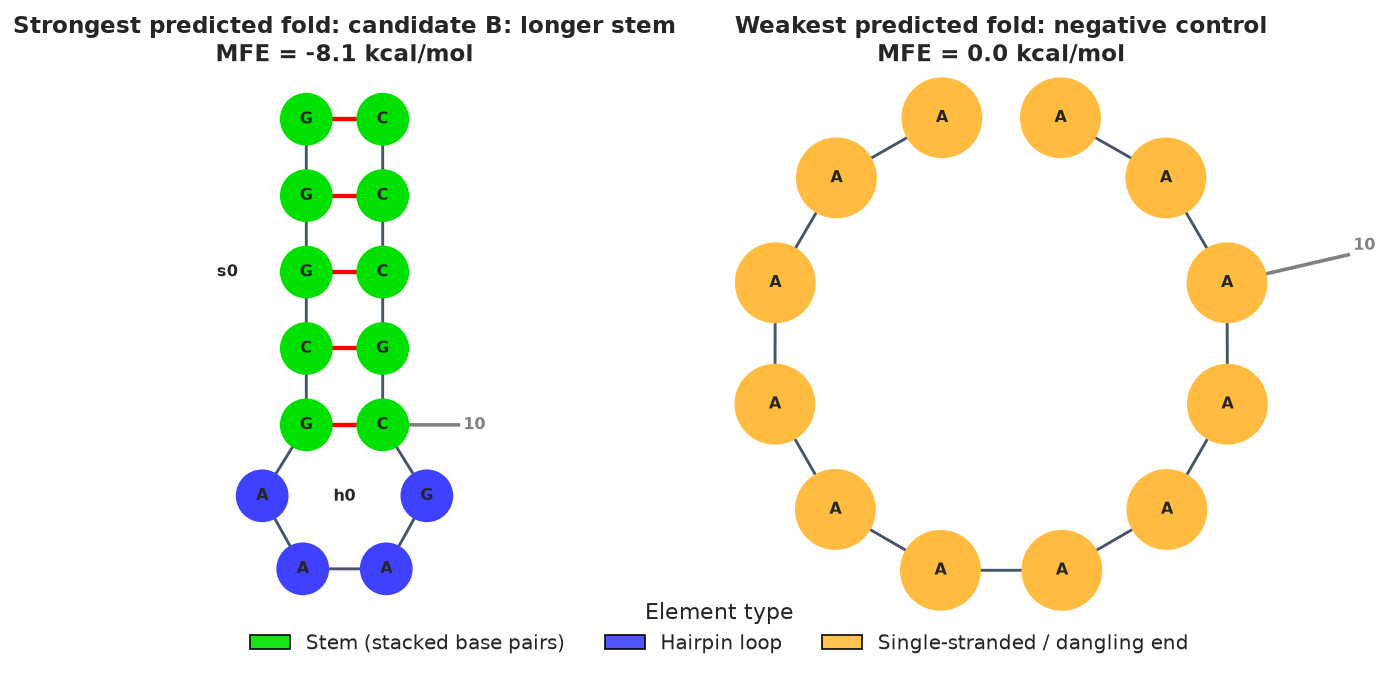

In [13]:
strongest = screen.sort_values("MFE energy (kcal/mol)").iloc[0]
weakest = screen.sort_values("MFE energy (kcal/mol)").iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, result, label in zip(axes, [strongest, weakest], ["Strongest predicted fold", "Weakest predicted fold"]):
    plot_forgi_structure(
        result["sequence"],
        result["MFE structure"],
        ax=ax,
        title=f"{label}: {result['name']}\nMFE = {result['MFE energy (kcal/mol)']} kcal/mol",
    )

handles = forgi_legend_handles(strongest["MFE structure"], weakest["MFE structure"])
fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False, bbox_to_anchor=(0.5, -0.05), title="Element type")
fig.tight_layout()


### Interpretation

The lollipop chart cleanly separates the structured hairpins from the unstructured
controls in this toy set, and the `forgi` diagrams make the *reason* visible: the
strongest candidate is almost entirely stem (green), while the weakest is a single
unstructured ring. Note that the "strongest" predicted fold is not automatically the
"best" design — applications that require switching, binding, or controlled
unfolding (e.g., riboswitches, toeholds) may deliberately target *moderate*
stability. A screen like this is a triage step, not a final design criterion.


## 9. Best practices and common pitfalls

| Situation | Don't | Do instead |
| :--- | :--- | :--- |
| Reading a single MFE structure | Treat it as "the" structure the molecule adopts | Remember it's the single lowest-energy structure under the model; nearby suboptimal structures may be biologically relevant too (later notebooks cover the partition function and suboptimal ensembles) |
| Comparing energies across sequences | Compare MFE values for sequences of very different lengths and conclude one is "more stable" in an absolute sense | Compare like with like (similar lengths/contexts), and treat energy differences as model-relative, not absolute physical measurements |
| Interpreting "0.0 kcal/mol" results | Assume the sequence has literally zero structure in reality | Recognize this means the model's *best* structure is the fully unfolded chain — under default settings, with default temperature/ions |
| Checking Python vs CLI agreement | Assume they always match | Confirm versions and model settings (temperature, parameter set) match if you need exact agreement across interfaces |
| Visualizing structures | Rely on only one plot type | Combine dot-bracket strings, tables, arc diagrams, mountain plots, pairing-matrix heatmaps, native SVG, and `forgi` element-type diagrams — each highlights different things |
| Designing sequences from a screen | Pick the single most negative MFE energy and stop | Use the screen as a triage step; consider the application's need for stability *vs.* switchability |
| Reproducibility | Hard-code results from "whatever version happens to be installed" | Print and record `RNA.__version__` and `forgi`'s version (as we did in Section 3) alongside any reported energies |

### The single most important caveat

Everything in this notebook is built on **one** structure: the MFE structure. Real
RNA molecules populate an *ensemble* of structures, and the MFE structure is just the
single most favorable one under the model. The next notebooks in this series build
toward the partition function and base-pair probabilities, which describe that whole
ensemble rather than just its single best member.


## 10. Summary and recap

This notebook covered the first complete ViennaRNA workflow:

- **The problem**: RNA secondary structure prediction asks for the structure $s^*$
  that minimizes a thermodynamic free-energy score $\Delta G(s \mid x)$, computed by
  summing contributions from stacked pairs and loops (the nearest-neighbor model).
- **The notation**: dot-bracket strings (`(`, `)`, `.`) compactly and exactly encode a
  secondary structure; tables, arc diagrams, mountain plots, pairing-matrix heatmaps,
  ViennaRNA's native SVG, and `forgi`'s element-type-colored diagrams are different
  views of the *same* information, each useful for a different purpose.
- **The simplest API**: `RNA.fold(sequence)` returns `(structure, energy)` — directly
  $s^*$ and $\Delta G(s^* \mid x)$.
- **The object-oriented API**: `RNA.fold_compound(sequence).mfe()` gives the same
  result, but the fold compound object is the interface reused for every later
  notebook (partition functions, suboptimal structures, constraints).
- **The CLI**: `RNAfold --noPS` is the command-line equivalent for a single sequence,
  and agrees with the Python results when model settings match.
- **The caveat**: an MFE prediction is one structure under one model — not proof of
  biological behavior, and not the whole story (the ensemble matters too).

These objectives map back to the learning goals at the top of the notebook — if any
of them still feel shaky, the exercises below are a good place to practice before
moving on.

**Next up:** Notebook 2 (`02_mfe_folding.ipynb`) goes deeper into MFE folding itself —
model settings (temperature, parameter sets), more about fold compounds, and how to
interpret energy differences between alternative structures for the *same* sequence.


## 11. Exercises

Try these before moving on to Notebook 2. No solutions are provided — use the
helper functions defined above (`fold_sequence`, `dotbracket_to_pairs`,
`plot_arc_diagram`, `plot_mountain`, `plot_pairing_matrix`, `plot_forgi_structure`,
`forgi_legend_handles`, `display_vienna_structure`).

1. **Read dot-bracket by hand.** Without running any code, write down the base pairs
   (as `(left, right)` position pairs) implied by the structure `((..(...)..))` for a
   12-nucleotide sequence of your choice. Then check your answer with
   `dotbracket_to_pairs`, and reproduce the four-panel figure from Section 4 (arc
   diagram, mountain plot, pairing-matrix heatmap, `forgi` diagram) for your
   structure. This structure contains an **interior loop** — which color does
   `forgi` use for it, and does that match the legend in `FORGI_ELEMENT_LEGEND`?

2. **Predict, then verify.** Pick three short sequences of your own (8-16 nt): one
   you expect to form a strong hairpin, one you expect to be weakly structured, and
   one you expect to be unstructured. Write down your predicted ranking of their MFE
   energies *before* running `fold_sequence` on each. How close was your ranking? If
   it was wrong, look at the predicted structures, energies, and `forgi` diagrams to
   see what intuition from Section 2.2 you might be missing.

3. **Single mutation, big effect.** Take the `"longer GC hairpin"` sequence from
   Section 6 (`GGGCGAAAGCGCCC`) and change a single nucleotide so that one of the
   stem base pairs can no longer form (e.g., change a `G` in the stem to an `A`).
   Re-fold both versions and compare their MFE structures and energies side by side
   (table + `forgi` diagrams in one figure, sharing a legend via
   `forgi_legend_handles`). How much did one mutation change the predicted
   structure? What does this suggest about using single-point mutations as *negative
   controls* in a screen like Section 8?
